In [1]:
from pathlib import Path
import re
import pandas as pd
import seaborn as sns

In [2]:
WORKLOADS = ["faiss_10M", "lulesh2.0_s400", "DuckDB-TPCH-sf100", "DuckDB-TPCDS-sf100", "mg.D.x", "XSBench", "pr-kron.sg", "pr-twitter.sg", "bc-kron.sg", "bc-twitter.sg"]

In [3]:
def parse_time_value(raw: str) -> float:
    """Convert strings like '7m56.676s' into seconds."""

    raw = raw.strip()
    match = re.fullmatch(r"(?:(\d+)m)?([0-9.]+)s", raw)
    if not match:
        raise ValueError(f"Unrecognized time format: {raw}")
    minutes = int(match.group(1) or 0)
    seconds = float(match.group(2))
    return minutes * 60 + seconds

def parse_time_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "\t" not in line:
                continue
            key, value = line.split("\t", 1)
            metrics[key] = parse_time_value(value)
    return metrics

def extract_mib(path: Path) -> int | None:
    match = re.search(r"(\d+)MiB", path.name)
    return int(match.group(1)) if match else None


def extract_run(path: Path) -> int | None:
    match = re.search(r"run(\d+)", path.name)
    return int(match.group(1)) if match else None

def parse_l2_value(raw: str) -> bool | int | float | str:
    if raw == "true":
        return True
    if raw == "false":
        return False
    if re.fullmatch(r"\d+", raw):
        return int(raw)
    if re.fullmatch(r"\d+\.\d+", raw):
        return float(raw)
    return raw

def parse_log_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "=" not in line:
                continue
            key, value = line.split("=", 1)
            metrics[key.strip()] = float(value.strip())
    return metrics

In [4]:
def generate_df(roots_gen: callable) -> pd.DataFrame:
    dfs = []

    for workload in WORKLOADS:
        records: list[dict] = []
        for label, (kernel, root) in roots_gen(workload).items():
            for path in sorted(root.glob("*.time")):
                if "train" in path.name:
                    continue
                metrics = parse_time_file(path)
                try:
                    log_metrics = parse_log_file(Path(f"{path.parent}/max_dram_hugepages_{path.stem}.log"))
                except FileNotFoundError:
                    log_metrics = {}

                m = re.search(
                    r"^(?P<mib>\d+)MiB_run(?P<run>\d+)_(?P<model>[^_]+)_discounted_reward_(?P<discounted_reward>\d+)_(?P<workload>.+)_l2-(?P<l2>[^_]+)_(?P<hist_length>\d+)_(?P<penalty>[0-9]+(?:\.[0-9]+)?)(?:\.time)?$",
                    path.name,
                )
                parsed = {}
                if m:
                    l2_value = parse_l2_value(m.group("l2"))
                    parsed = {
                        "MiB": int(m.group("mib")),
                        "run": int(m.group("run")),
                        "model": m.group("model"),
                        "filename_workload": m.group("workload"),
                        "discounted_reward": int(m.group("discounted_reward")),
                        "l2": l2_value,
                        "minmax": l2_value if isinstance(l2_value, bool) else None,
                        "hist_length": int(m.group("hist_length")),
                        "penalty": float(m.group("penalty")),
                    }

                records.append({
                    "policy": label,
                    "kernel": kernel,
                    "file": path.name,
                    "MiB": extract_mib(path),
                    "run": extract_run(path),
                    **metrics,
                    **log_metrics,
                    **parsed,
                })

        df = pd.DataFrame(records)
        df["workload"] = workload

        dfs.append(df)
    df = pd.concat(dfs, ignore_index=True)
    return df

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
    
def plot_df(df: pd.DataFrame):

    policy_order = list(dict.fromkeys(df["policy_penalty"]))
    policy_palette = dict(zip(policy_order, sns.color_palette(n_colors=len(policy_order))))

    def minmax_interval(values):
        return values.min(), values.max()

    for workload_group in df.groupby("workload"):
        print(workload_group[0])
        plt.figure(figsize=(14, 8))
        ax = sns.barplot(
            workload_group[1],
            x="MiB",
            y="real",
            hue="policy_penalty",
            hue_order=policy_order,
            palette=policy_palette,
            estimator="mean",
            errorbar=minmax_interval,
        )
        ax.set(title=workload_group[0], xlabel="Memory Footprint (MiB)", ylabel="Execution Time (s)")

        for container in ax.containers:
            labels = [f"{value:.2f}" if pd.notna(value) else "" for value in container.datavalues]
            ax.bar_label(container, labels=labels, padding=3, fontsize=9)

        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax * 1.08)

        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
        plt.tight_layout()
        plt.show()

In [6]:
roots_6_18 = lambda workload: {
        #"arms 6.18": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/arms-6.18/{workload}")),
        "arms 6.18": ("6.18", Path(f"/home/freischuetz/memory_tiering/tiering_solutions/times/gsl_optane/arms/{workload}")),
        "model 6.18": ("6.18", Path(f"/home/freischuetz/memory_tiering/tiering_solutions/times/gsl_optane/model/{workload}")),
    }

df = generate_df(roots_6_18)

In [7]:
df

,policy,kernel,file,MiB,run,real,user,sys,model,filename_workload,discounted_reward,l2,minmax,hist_length,penalty,workload
0,arms 6.18,6.18,1MiB_run1.time,1.0,1.0,0.207,0.005,0.015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,faiss_10M
1,arms 6.18,6.18,4002MiB_run1.time,4002.0,1.0,464.123,0.034,0.081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,faiss_10M
2,arms 6.18,6.18,4003MiB_run1.time,4003.0,1.0,462.821,0.031,0.089,NaN,NaN,NaN,NaN,NaN,NaN,NaN,faiss_10M
3,arms 6.18,6.18,4003MiB_run2.time,4003.0,2.0,462.231,0.038,0.087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,faiss_10M
4,arms 6.18,6.18,4003MiB_run3.time,4003.0,3.0,459.426,0.021,0.102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,faiss_10M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,model 6.18,6.18,8002MiB_run3_model_discounted_reward_99_bc-twi...,8002.0,3.0,330.142,0.024,0.104,model,bc-twitter.sg,99.0,2.0,NaN,10.0,0.125,bc-twitter.sg
568,model 6.18,6.18,8002MiB_run3_model_discounted_reward_99_bc-twi...,8002.0,3.0,274.023,0.020,0.087,model,bc-twitter.sg,99.0,2.0,NaN,10.0,0.250,bc-twitter.sg
569,model 6.18,6.18,8002MiB_run3_model_discounted_reward_99_bc-twi...,8002.0,3.0,262.718,0.022,0.081,model,bc-twitter.sg,99.0,2.0,NaN,10.0,0.500,bc-twitter.sg
570,model 6.18,6.18,8002MiB_run3_model_discounted_reward_99_bc-twi...,8002.0,3.0,262.708,0.020,0.090,model,bc-twitter.sg,99.0,2.0,NaN,10.0,1.000,bc-twitter.sg


In [8]:
df_plot = df[df["MiB"].isin([4003, 6003, 8002, 10002])]
df_plot["policy_penalty"] = df_plot.apply(lambda row: f"{row['policy']} {row['penalty']}", axis=1)

XSBench


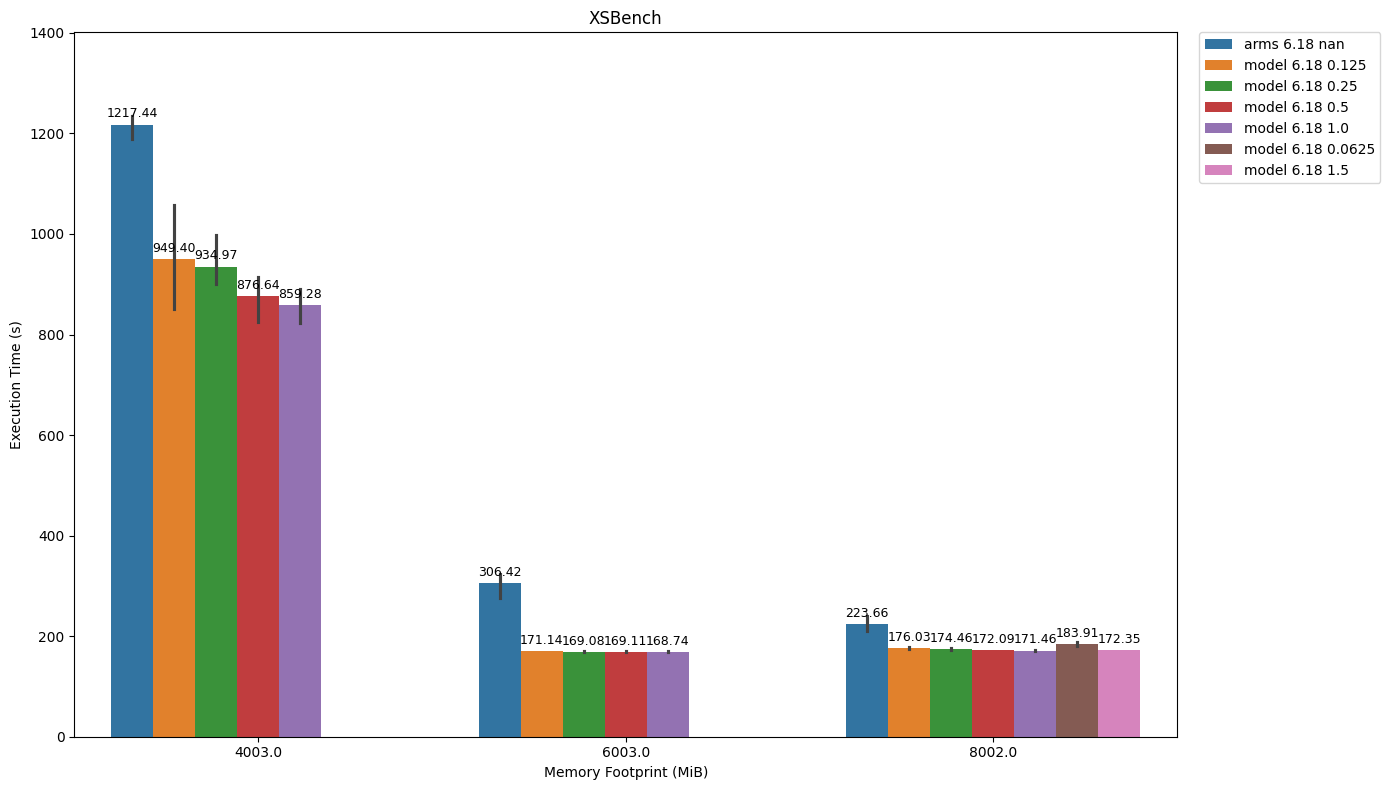

bc-kron.sg


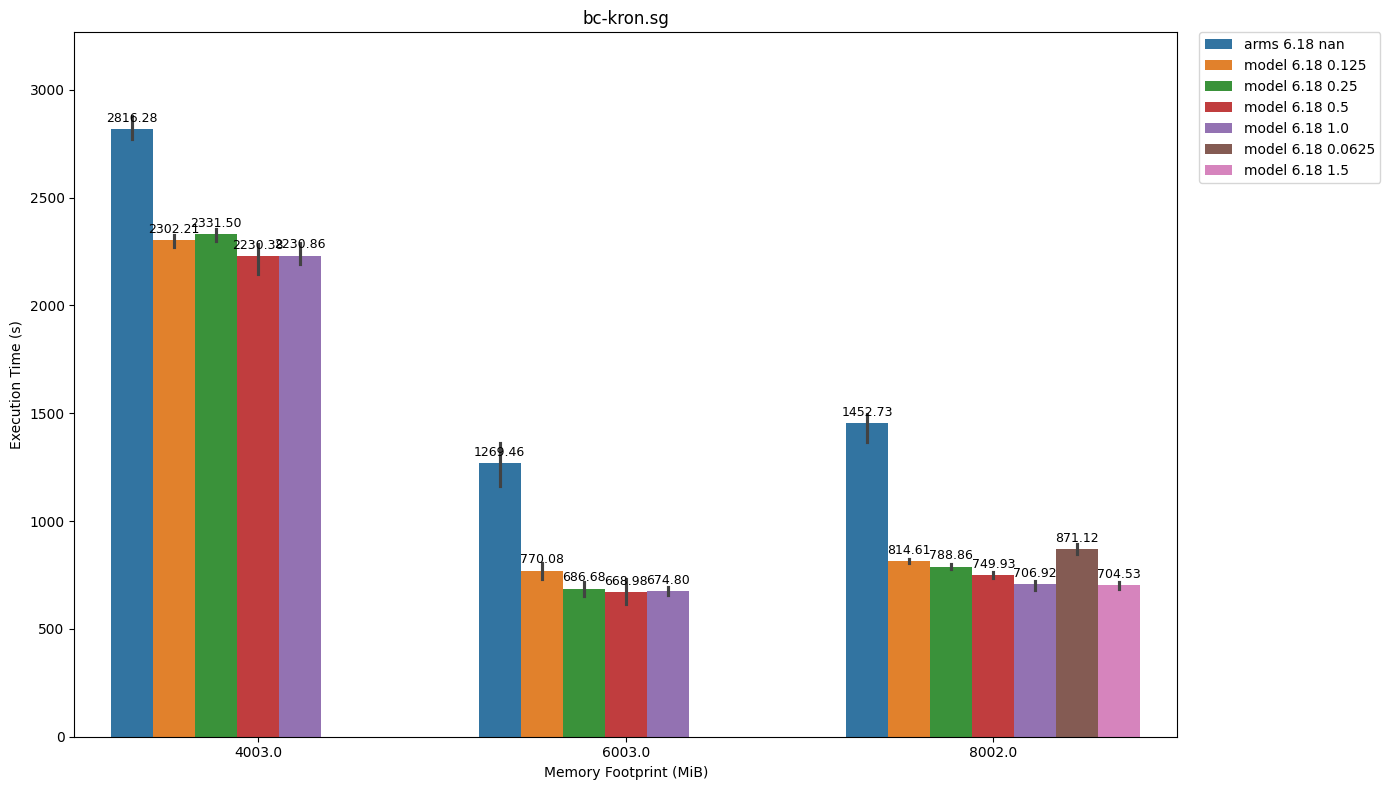

bc-twitter.sg


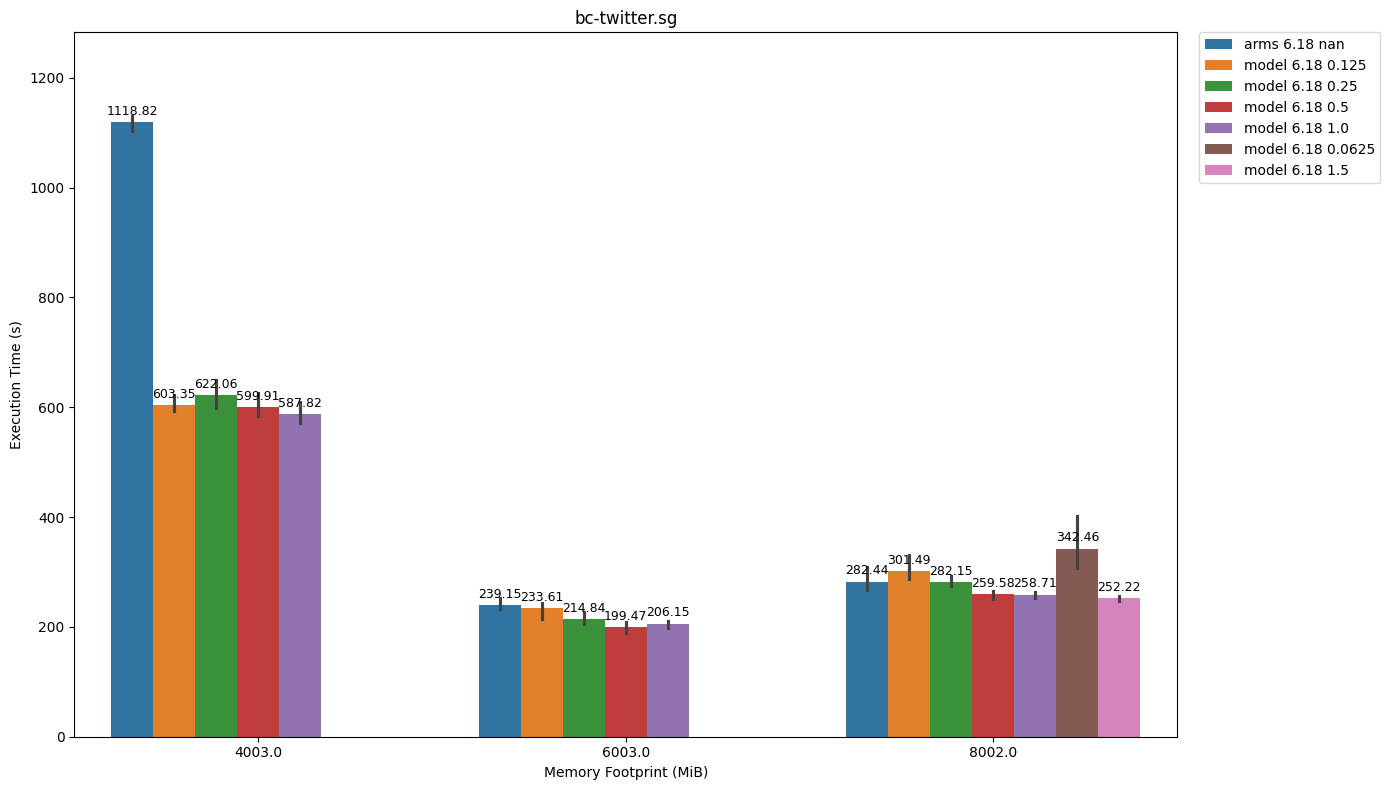

faiss_10M


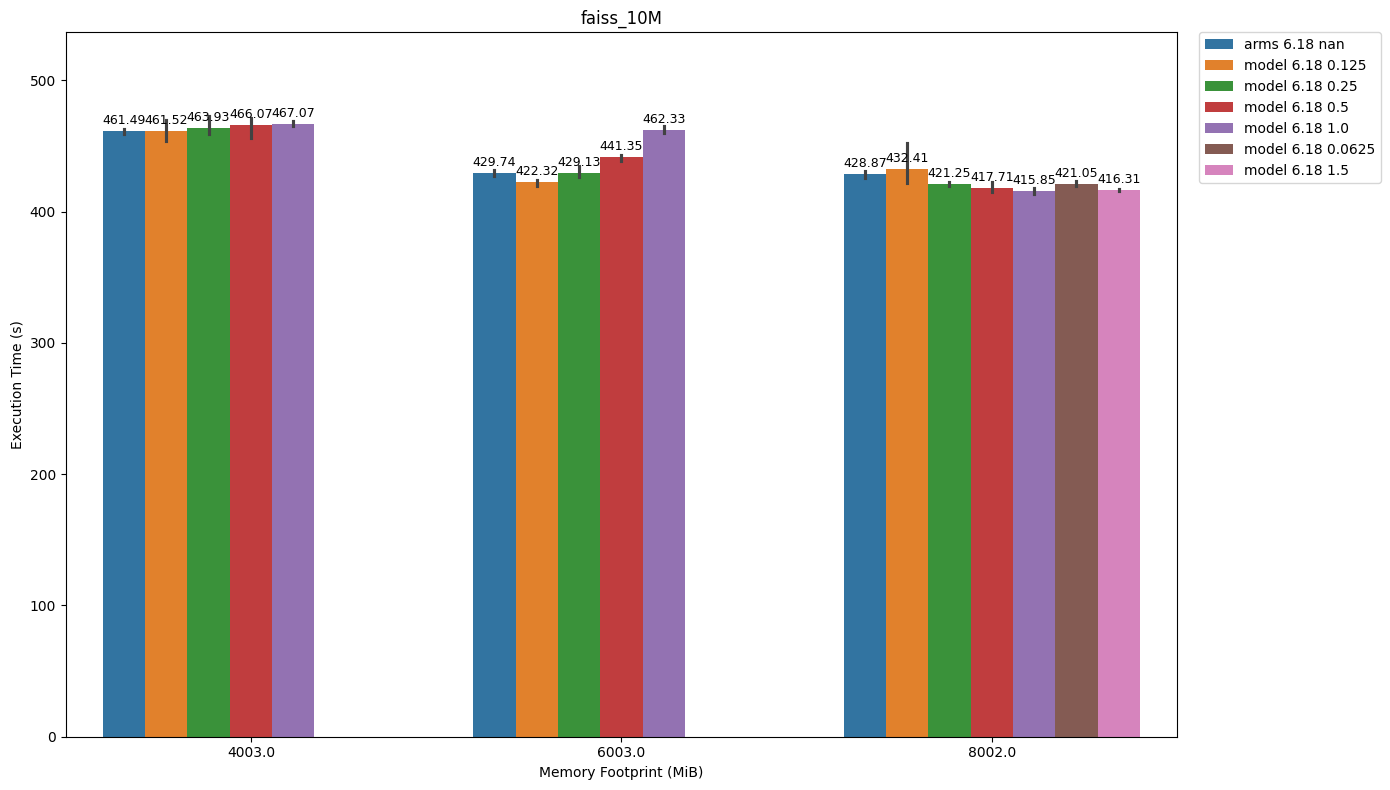

pr-kron.sg


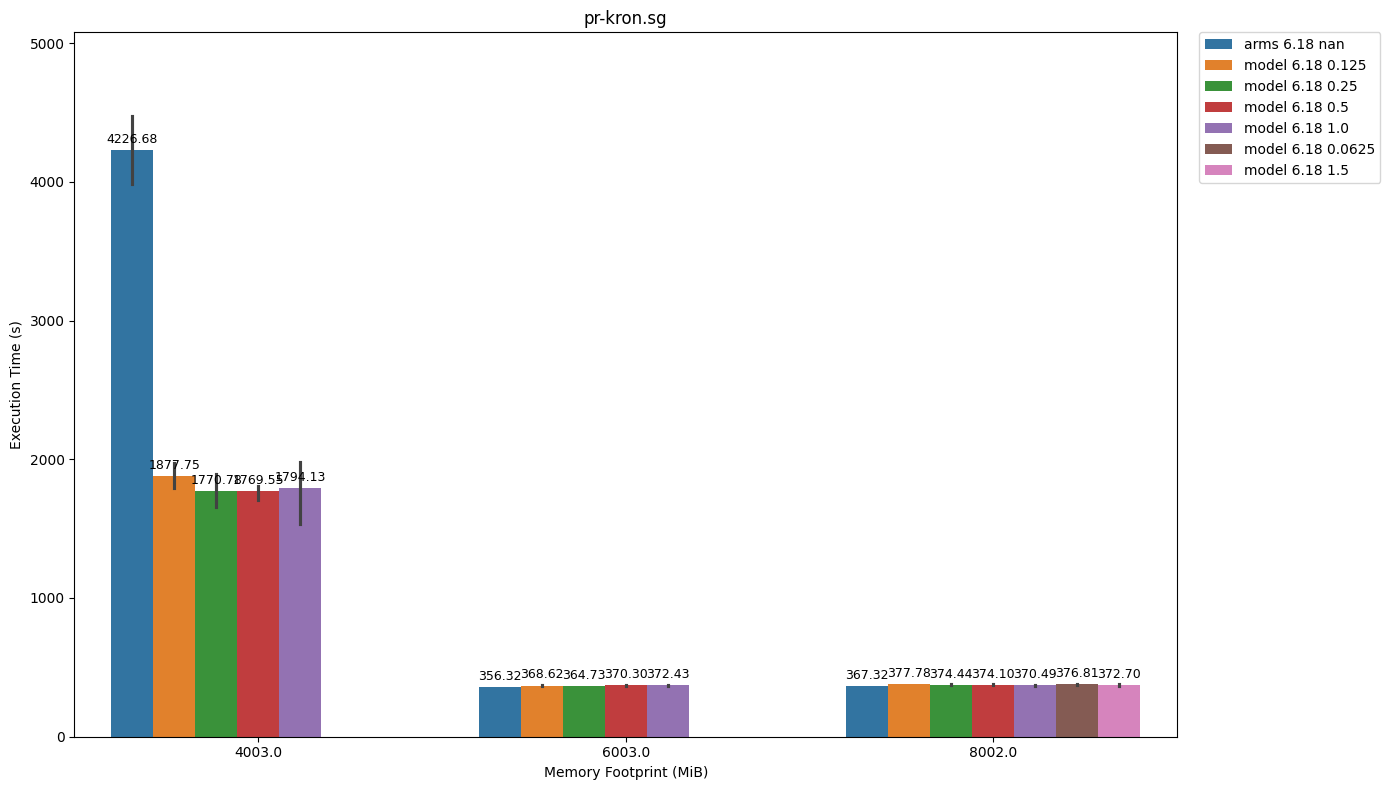

pr-twitter.sg


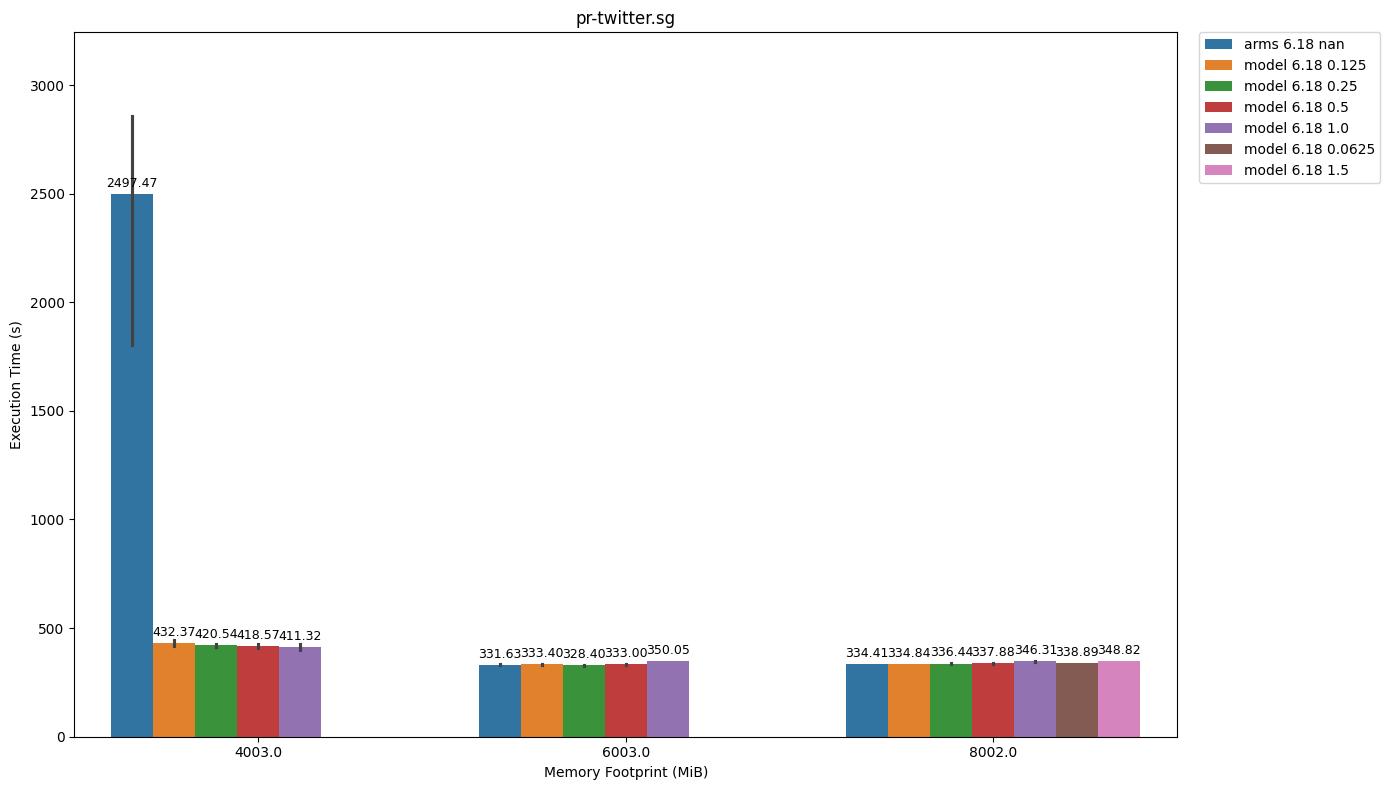

In [9]:
plot_df(df_plot)